## Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("D:\Portfolio Optimization using SPO\data\portfolio_dataset.csv")
df.head()

,Date,Ticker,RET_1D,RET_5D,RET_10D,MOM_10,MOM_20,VOL_5,VOL_10,ALPHA_1D,RANK_MOM_10,ANTI_MOM_10,TARGET_CLASS,TARGET_RETURN
0,2018-01-31,AAPL,0.002755,-0.038974,-0.065159,-0.065159,-0.028039,0.011013,0.008756,0.001972,4.0,0.065159,0.0,-0.047124
1,2018-01-31,ABBV,-0.031584,0.063596,0.075316,0.075316,0.148511,0.074853,0.050858,-0.032367,59.0,-0.075316,1.0,0.012476
2,2018-01-31,ABT,-0.004484,0.007129,0.053738,0.053738,0.062379,0.014154,0.016201,-0.005267,53.0,-0.053738,0.0,-0.056145
3,2018-01-31,ACN,0.006262,0.000623,0.003059,0.003059,0.044592,0.008885,0.006493,0.005479,26.0,-0.003059,0.0,-0.034537
4,2018-01-31,AMD,0.067599,0.081039,0.128079,0.128079,0.251366,0.043656,0.031487,0.066816,63.0,-0.128079,0.0,-0.155750


In [3]:
df.isnull().sum()

Date             0
Ticker           0
RET_1D           0
RET_5D           0
RET_10D          0
MOM_10           0
MOM_20           0
VOL_5            0
VOL_10           0
ALPHA_1D         0
RANK_MOM_10      0
ANTI_MOM_10      0
TARGET_CLASS     0
TARGET_RETURN    0
dtype: int64

In [4]:
df.columns

Index(['Date', 'Ticker', 'RET_1D', 'RET_5D', 'RET_10D', 'MOM_10', 'MOM_20',
       'VOL_5', 'VOL_10', 'ALPHA_1D', 'RANK_MOM_10', 'ANTI_MOM_10',
       'TARGET_CLASS', 'TARGET_RETURN'],
      dtype='object')

## What does each column represent 

MA7 -> Moving averages over 7 days

MA30 -> Moving averages over 30 days

Both are used for trend detection


VOL -> Volume of the trade

Use Case : Measures market participation / strength


MOM -> Momentum
Measures speed of price movement

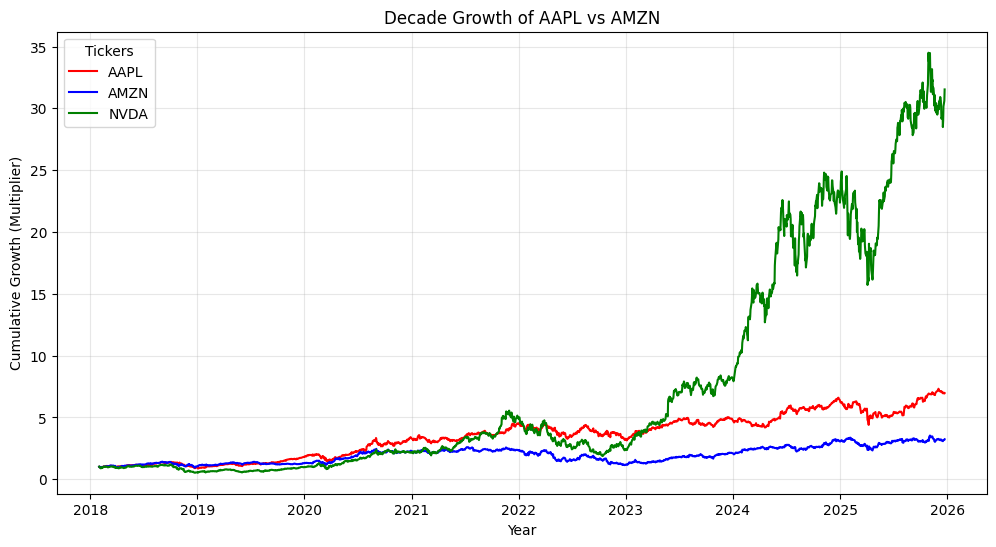

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Choose the stock you want to visualize
stock_ticker = "AAPL" 
stock_ticker2 = "AMZN"
stock_ticker3 = "NVDA"
stock_data = df[df['Ticker'] == stock_ticker].copy()
stock_data2 = df[df['Ticker'] == stock_ticker2].copy()
stock_data3 = df[df['Ticker'] == stock_ticker3].copy()
# 2. Sort by date just to be absolutely sure chronologically
stock_data['Date'] = pd.to_datetime(stock_data['Date'])
stock_data = stock_data.sort_values('Date')
stock_data2['Date'] = pd.to_datetime(stock_data2['Date'])
stock_data2 = stock_data2.sort_values('Date')
stock_data3['Date'] = pd.to_datetime(stock_data3['Date'])
stock_data3 = stock_data3.sort_values('Date')
# 3. Calculate Cumulative Return (Growth of $1 over time)
stock_data['Cumulative_Growth'] = (1+stock_data['RET_1D']).cumprod()
stock_data2['Cumulative_Growth'] = (1+stock_data2['RET_1D']).cumprod()
stock_data3['Cumulative_Growth'] = (1+stock_data3['RET_1D']).cumprod()
# 4. Plot the Growth
plt.figure(figsize=(12, 6))

# ADDED: label parameters here
sns.lineplot(data=stock_data, x='Date', y='Cumulative_Growth', color="red", label=stock_ticker)
sns.lineplot(data=stock_data2, x='Date', y='Cumulative_Growth', color="blue", label=stock_ticker2)
sns.lineplot(data=stock_data3, x='Date', y='Cumulative_Growth', color="green", label=stock_ticker3)
plt.title(f'Decade Growth of {stock_ticker} vs {stock_ticker2}')
plt.xlabel('Year')
plt.ylabel('Cumulative Growth (Multiplier)')
plt.grid(True, alpha=0.3)

# ADDED: plt.legend() to actually show the box
plt.legend(title="Tickers") 

plt.show()
